# PPO를 이용한 RLHF 실습

이 노트에서는 **PPO(Proximal Policy Optimization)**를 이용해 언어 모델의 출력 성향을 보상 모델 방향으로 조정하는 과정을 실습한다.

## 학습 목표

이 실습을 통해 다음 내용을 이해한다.

- RLHF에서 policy model, reference model, reward model, value model이 각각 어떤 역할을 하는지 이해한다.
- IMDb 데이터를 PPO rollout용 prompt 데이터로 전처리한다.
- 감성 분류 모델을 scalar reward model 형태로 변환해 보상으로 사용한다.
- 최신 TRL의 `PPOTrainer`로 policy를 학습한다.
- PPO 학습 전후의 출력과 감성 점수를 비교한다.
- 긍정 보상과 부정 보상을 각각 적용했을 때 policy가 어떻게 달라지는지 확인한다.

## 1. 환경 설정

### 1.1 라이브러리 설치

최신 Hugging Face/TRL API를 사용한다. `torch`는 따로 설치하지 않는다. Colab GPU 런타임에는 CUDA용 PyTorch가 이미 설치되어 있기 때문이다.

In [1]:
%%time

%pip install -q -U \
  "trl==1.9.0" \
  "transformers==5.14.1" \
  "peft==0.19.1" \
  "datasets==5.0.0" \
  "accelerate==1.14.0" \
  "matplotlib==3.11.1" \
  "pandas"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
CPU times: user 1.57 s, sys: 480 ms, total: 2.05 s
Wall time: 1min 9s


### 1.2 GPU 및 패키지 버전 확인

In [2]:
import importlib.metadata as metadata
import torch

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU가 잡히지 않았다. Colab 메뉴에서 런타임 > 런타임 유형 변경 > T4 GPU 등을 선택한다.")

for package in ["trl", "transformers", "peft", "datasets", "accelerate"]:
    print(f"{package}: {metadata.version(package)}")

PyTorch: 2.11.0+cpu
CUDA 사용 가능: False
GPU가 잡히지 않았다. Colab 메뉴에서 런타임 > 런타임 유형 변경 > T4 GPU 등을 선택한다.
trl: 1.9.0
transformers: 5.14.1
peft: 0.19.1
datasets: 5.0.0
accelerate: 1.14.0


### 1.3 필요한 라이브러리 import

In [13]:
import gc
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
    set_seed,
)
from trl.experimental.ppo import PPOConfig, PPOTrainer

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

사용 device: cpu


## 2. PPO에서 사용하는 모델 구조

최신 `PPOTrainer`는 다음 모델들을 따로 받는다.

- **Policy model**: 실제로 업데이트되는 생성 모델이다.
- **Reference model**: 초기 policy와 너무 멀어지지 않도록 KL divergence를 계산할 때 기준이 된다.
- **Reward model**: 생성된 응답에 scalar reward를 준다.
- **Value model**: 각 상태의 기대 보상을 추정해 advantage 계산에 사용한다.

In [4]:
POLICY_CHECKPOINT = "lvwerra/gpt2-imdb"
REWARD_CHECKPOINT = "mnoukhov/gpt2-imdb-sentiment-classifier"
EVAL_SENTIMENT_CHECKPOINT = "lvwerra/distilbert-imdb"

print("Policy:", POLICY_CHECKPOINT)
print("Reward source:", REWARD_CHECKPOINT)

Policy: lvwerra/gpt2-imdb
Reward source: mnoukhov/gpt2-imdb-sentiment-classifier


### 2.1 토크나이저 준비

In [5]:
tokenizer = AutoTokenizer.from_pretrained(POLICY_CHECKPOINT)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("pad_token:", tokenizer.pad_token)
print("eos_token:", tokenizer.eos_token)

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

pad_token: <|endoftext|>
eos_token: <|endoftext|>


## 3. IMDb 데이터셋 전처리

PPO에서는 정답 문장을 그대로 학습하는 것이 아니라, **prompt를 policy에 넣고 policy가 직접 response를 생성한 뒤 reward를 받는 on-policy rollout**이 핵심이다.

여기서는 IMDb 리뷰의 앞부분을 짧은 prompt로 사용한다. 너무 짧은 리뷰는 제거하고, 각 샘플마다 8~32개 토큰 정도를 prompt로 사용한다.

In [7]:
raw_dataset = load_dataset(
    "stanfordnlp/imdb",
    "plain_text",
    split="train"
)

raw_dataset = raw_dataset.filter(lambda x: len(x["text"]) > 200)
raw_dataset = raw_dataset.shuffle(seed=42)

MAX_SAMPLES = min(1200, len(raw_dataset))
raw_dataset = raw_dataset.select(range(MAX_SAMPLES))

print(raw_dataset)
print(raw_dataset[0]["text"][:300])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 1200
})
I think this is almost all I need to say. I feel obliged to explain my actions though. I've basically never seen such an armateur production, and I mean that in all senses of the word. Although the physical camera work, boom MIC operation and other technical aspects of this film are laughable, unfor


### 3.1 prompt 길이를 무작위로 정해 토큰화한다

In [8]:
rng = random.Random(42)

def make_prompt(example):
    token_ids = tokenizer.encode(example["text"], add_special_tokens=False)
    prompt_length = min(len(token_ids), rng.randint(8, 32))
    prompt_ids = token_ids[:prompt_length]
    return {"input_ids": prompt_ids}

ppo_dataset = raw_dataset.map(make_prompt, remove_columns=raw_dataset.column_names)
ppo_dataset = ppo_dataset.train_test_split(test_size=100, seed=42)

train_dataset = ppo_dataset["train"]
eval_dataset = ppo_dataset["test"]

print(train_dataset)
print("예시 prompt:", tokenizer.decode(train_dataset[0]["input_ids"]))

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1586 > 1024). Running this sequence through the model will result in indexing errors


Dataset({
    features: ['input_ids'],
    num_rows: 1100
})
예시 prompt: The premise of an African-American female Scrooge in the modern, struggling city was inspired, but nothing else in this


## 4. Reward model 만들기

원본 실습은 IMDb sentiment classifier의 점수를 reward로 사용했다. 최신 `PPOTrainer`는 학습 중 내부에서 직접 호출할 수 있는 **1개의 scalar 값을 출력하는 reward model**을 요구한다.

따라서 2-class 감성 분류기의 두 logit 차이를 이용해 1차원 reward head를 만든다.

- 긍정 PPO: `positive_logit - negative_logit`이 클수록 높은 reward를 준다.
- 부정 PPO: 위 값의 부호를 반대로 하여 부정적인 문장일수록 높은 reward를 준다.

이 변환은 분류기의 기존 표현층은 유지하고 마지막 classification head만 scalar 형태로 바꾸는 방식이다.

In [14]:
def build_scalar_reward_model(sign=1.0):
    """2-class sentiment classifier를 1개의 scalar reward를 출력하도록 변환한다."""

    # 기존 2-class sentiment model
    source = AutoModelForSequenceClassification.from_pretrained(
        REWARD_CHECKPOINT
    )

    # 기존 config를 먼저 불러온다.
    reward_config = AutoConfig.from_pretrained(REWARD_CHECKPOINT)

    # 최신 Transformers에서는 이 순서가 중요하다.
    reward_config.problem_type = "regression"
    reward_config.num_labels = 1

    # 같은 backbone을 사용하되 출력 head를 1차원 scalar reward로 만든다.
    reward_model = AutoModelForSequenceClassification.from_pretrained(
        REWARD_CHECKPOINT,
        config=reward_config,
        ignore_mismatched_sizes=True,
    )

    label2id = {
        str(k).lower(): int(v)
        for k, v in source.config.label2id.items()
    }

    positive_idx = next(
        (v for k, v in label2id.items() if "pos" in k),
        1
    )
    negative_idx = next(
        (v for k, v in label2id.items() if "neg" in k),
        0
    )

    # GPT-2 sequence classification head의 이름은 score다.
    if not hasattr(source, "score") or not hasattr(reward_model, "score"):
        raise AttributeError(
            "이 실습은 'score' classification head를 가진 "
            "GPT-2 계열 reward model을 기준으로 한다."
        )

    with torch.no_grad():
        diff_w = (
            source.score.weight[positive_idx]
            - source.score.weight[negative_idx]
        )

        reward_model.score.weight[0].copy_(
            float(sign) * diff_w
        )

        if (
            source.score.bias is not None
            and reward_model.score.bias is not None
        ):
            diff_b = (
                source.score.bias[positive_idx]
                - source.score.bias[negative_idx]
            )

            reward_model.score.bias[0].copy_(
                float(sign) * diff_b
            )

    reward_model.config.pad_token_id = reward_tokenizer.pad_token_id

    del source

    return reward_model

### 4.1 Reward model 동작을 간단히 확인한다

In [15]:
reward_tokenizer = AutoTokenizer.from_pretrained(REWARD_CHECKPOINT)
if reward_tokenizer.pad_token is None:
    reward_tokenizer.pad_token = reward_tokenizer.eos_token

positive_reward_model = build_scalar_reward_model(sign=1.0).to(device)
positive_reward_model.eval()

samples = ["This movie was wonderful and moving.", "This movie was boring and terrible."]
encoded = reward_tokenizer(samples, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    rewards = positive_reward_model(**encoded).logits.squeeze(-1)

for text, reward in zip(samples, rewards.tolist()):
    print(f"reward={reward: .4f} | {text}")

# PPOTrainer를 만들 때 다시 로드할 것이므로 GPU 메모리를 비운다.
del positive_reward_model, encoded
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: mnoukhov/gpt2-imdb-sentiment-classifier
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: mnoukhov/gpt2-imdb-sentiment-classifier
Key                                     | Status     |                                                                                       
----------------------------------------+------------+---------------------------------------------------------------------------------------
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |                                                                                       
score.weight                            | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([2, 768]) vs model:torch.Size([1, 768])

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


reward= 7.0042 | This movie was wonderful and moving.
reward=-8.2777 | This movie was boring and terrible.


## 5. PPO 설정

PPO의 핵심 목적은 reward를 높이면서도 reference policy에서 지나치게 멀어지지 않도록 하는 것이다.

개념적으로는 다음과 같이 볼 수 있다.

**objective = reward - beta × KL(policy || reference)**

최신 TRL에서는 rollout 생성, reward 계산, advantage 계산, PPO clipping, KL 제어를 `PPOTrainer.train()` 내부에서 처리한다. 예전 버전처럼 사용자가 매 batch마다 `generate()`와 `step()`을 직접 호출하지 않는다.

In [16]:
def make_ppo_config(output_dir):
    return PPOConfig(
        output_dir=output_dir,
        learning_rate=1.41e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        total_episodes=128,
        num_ppo_epochs=2,
        num_mini_batches=1,
        response_length=24,
        local_rollout_forward_batch_size=4,
        temperature=0.7,
        stop_token="eos",
        kl_coef=0.05,
        cliprange=0.2,
        gradient_checkpointing=False,
        fp16=torch.cuda.is_available(),
        bf16=False,
        use_cpu=not torch.cuda.is_available(),
        logging_steps=1,
        save_strategy="no",
        report_to="none",
        num_sample_generations=0,
        seed=42,
    )

### 5.1 최신 `PPOTrainer` 생성 함수

In [17]:
def build_ppo_trainer(reward_sign, output_dir):
    policy = AutoModelForCausalLM.from_pretrained(POLICY_CHECKPOINT)
    ref_policy = AutoModelForCausalLM.from_pretrained(POLICY_CHECKPOINT)

    if policy.config.pad_token_id is None:
        policy.config.pad_token_id = tokenizer.pad_token_id
    if ref_policy.config.pad_token_id is None:
        ref_policy.config.pad_token_id = tokenizer.pad_token_id

    reward_model = build_scalar_reward_model(sign=reward_sign)

    # PPO에서 state value를 예측하기 위한 별도 scalar value head다.
    value_model = AutoModelForSequenceClassification.from_pretrained(
        POLICY_CHECKPOINT,
        num_labels=1,
        ignore_mismatched_sizes=True,
    )
    value_model.config.pad_token_id = tokenizer.pad_token_id

    trainer = PPOTrainer(
        args=make_ppo_config(output_dir),
        processing_class=tokenizer,
        model=policy,
        ref_model=ref_policy,
        reward_model=reward_model,
        value_model=value_model,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
    )
    return trainer

## 6. 긍정적인 sentiment를 보상하도록 PPO 학습

`reward_sign=+1`로 두면 긍정 logit이 부정 logit보다 클수록 reward가 커진다.

실습 시간을 줄이기 위해 기본 설정은 128 episodes만 수행한다. 더 확실한 변화를 보고 싶다면 `total_episodes`를 늘리면 된다.

In [18]:
TRAIN_POSITIVE = True
POSITIVE_DIR = "./ppo_positive"

if TRAIN_POSITIVE:
    positive_trainer = build_ppo_trainer(reward_sign=1.0, output_dir=POSITIVE_DIR)
    positive_result = positive_trainer.train()
    positive_trainer.save_model(POSITIVE_DIR)
    tokenizer.save_pretrained(POSITIVE_DIR)
    print("긍정 PPO 모델 저장:", POSITIVE_DIR)
else:
    print("TRAIN_POSITIVE=False이므로 학습을 건너뛴다.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  548MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

...

[transformers] GPT2ForSequenceClassification LOAD REPORT from: lvwerra/gpt2-imdb
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Passing `generation_config` together with generation-related arguments=({'output_scores', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


===training policy===


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

긍정 PPO 모델 저장: ./ppo_positive


### 6.1 학습 로그 확인

In [19]:
if TRAIN_POSITIVE:
    positive_log = pd.DataFrame(positive_trainer.state.log_history)
    display(positive_log.tail())

,eps,objective/kl,objective/entropy,objective/non_score_reward,objective/rlhf_reward,objective/scores,policy/approxkl_avg,policy/clipfrac_avg,loss/policy_avg,loss/value_avg,val/clipfrac_avg,policy/entropy_avg,val/ratio,val/ratio_var,val/num_eos_tokens,lr,episode,epoch,step
11,0,0.052908,43.323574,-0.002645,0.073908,0.076554,0.000034,0.0,-0.019803,7.188024,0.0,2.126877,1.000160,4.015621e-07,14,4.406250e-06,96,0.087273,12
12,0,0.587912,43.183121,-0.029396,-0.607733,-0.578337,0.000020,0.0,-0.002555,8.694385,0.0,2.116487,0.999691,1.294463e-07,0,3.525000e-06,104,0.094545,13
13,0,0.644932,50.359600,-0.032247,0.642682,0.674929,0.000017,0.0,-0.001996,6.822414,0.0,2.041466,0.999529,3.716984e-07,0,2.643750e-06,112,0.101818,14
14,0,0.969211,44.043823,-0.048461,2.145994,2.194454,0.000003,0.0,-0.004300,7.567247,0.0,2.002307,1.000010,1.508396e-08,13,1.762500e-06,120,0.109091,15
15,0,0.262864,48.228405,-0.013143,3.396310,3.409453,0.000002,0.0,-0.000939,5.700216,0.0,2.073557,0.999869,3.086142e-08,9,8.812500e-07,128,0.116364,16


### 6.2 GPU 메모리 정리

In [20]:
if "positive_trainer" in globals():
    del positive_trainer

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 7. 부정적인 sentiment를 보상하도록 PPO 학습

이번에는 reward의 부호를 반대로 한다. 즉, 원래 감성 분류기가 더 부정적이라고 판단할수록 reward가 커진다.

In [22]:
TRAIN_NEGATIVE = True
NEGATIVE_DIR = "./ppo_negative"

if TRAIN_NEGATIVE:
    negative_trainer = build_ppo_trainer(reward_sign=-1.0, output_dir=NEGATIVE_DIR)
    negative_result = negative_trainer.train()
    negative_trainer.save_model(NEGATIVE_DIR)
    tokenizer.save_pretrained(NEGATIVE_DIR)
    print("부정 PPO 모델 저장:", NEGATIVE_DIR)
else:
    print("TRAIN_NEGATIVE=False이므로 학습을 건너뛴다.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: mnoukhov/gpt2-imdb-sentiment-classifier
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

...

[transformers] GPT2ForSequenceClassification LOAD REPORT from: lvwerra/gpt2-imdb
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


===training policy===


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

부정 PPO 모델 저장: ./ppo_negative


### 7.1 학습 로그 확인

In [23]:
if TRAIN_NEGATIVE:
    negative_log = pd.DataFrame(negative_trainer.state.log_history)
    display(negative_log.tail())

,eps,objective/kl,objective/entropy,objective/non_score_reward,objective/rlhf_reward,objective/scores,policy/approxkl_avg,policy/clipfrac_avg,loss/policy_avg,loss/value_avg,val/clipfrac_avg,policy/entropy_avg,val/ratio,val/ratio_var,val/num_eos_tokens,lr,episode,epoch,step
11,0,0.125327,42.255260,-0.006266,-0.509706,-0.503440,0.000054,0.0,-0.024017,8.765728,0.0,1.912469,0.999642,3.176960e-06,14,4.406250e-06,96,0.087273,12
12,0,-0.141791,49.659954,0.007090,-1.048101,-1.055190,0.000079,0.0,-0.003524,2.759821,0.0,2.145561,1.000097,1.149747e-06,0,3.525000e-06,104,0.094545,13
13,0,0.718231,41.495449,-0.035912,1.205754,1.241666,0.000011,0.0,0.022041,4.430742,0.0,1.950376,1.000028,1.843188e-06,22,2.643750e-06,112,0.101818,14
14,0,-0.341832,48.057735,0.017092,-0.317117,-0.334209,0.000007,0.0,0.014752,8.965536,0.0,1.943121,0.999948,7.654648e-07,5,1.762500e-06,120,0.109091,15
15,0,0.490085,34.308186,-0.024504,-1.532902,-1.508398,0.000001,0.0,0.019208,4.954288,0.0,1.791163,1.000028,6.022711e-08,30,8.812500e-07,128,0.116364,16


### 7.2 GPU 메모리 정리

In [24]:
if "negative_trainer" in globals():
    del negative_trainer

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 8. PPO 모델과 기준 모델 비교

학습에 사용한 reward model과 별개로, 비교용 IMDb sentiment pipeline을 사용한다. 이렇게 하면 생성 결과가 실제로 긍정/부정 방향으로 이동했는지 확인하기 쉽다.

In [25]:
sentiment_device = 0 if torch.cuda.is_available() else -1
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=EVAL_SENTIMENT_CHECKPOINT,
    device=sentiment_device,
    top_k=None,
)

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  268MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### 8.1 생성 함수

In [26]:
def load_generation_model(path_or_name):
    model = AutoModelForCausalLM.from_pretrained(path_or_name).to(device)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.eval()
    return model

@torch.inference_mode()
def generate_text(model, prompt, max_new_tokens=32):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_p=0.9,
        temperature=0.8,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

def positive_probability(text):
    result = sentiment_pipe(text)[0]
    score_map = {item["label"].upper(): item["score"] for item in result}
    for key, value in score_map.items():
        if "POS" in key or key.endswith("1"):
            return float(value)
    # label 이름을 알 수 없을 때 두 번째 class가 positive라는 IMDb 관례를 사용한다.
    return float(result[-1]["score"])

### 8.2 같은 prompt로 세 모델을 비교한다

In [27]:
PROMPT = "This movie"

base_model = load_generation_model(POLICY_CHECKPOINT)
positive_model = load_generation_model(POSITIVE_DIR) if Path(POSITIVE_DIR).exists() else None
negative_model = load_generation_model(NEGATIVE_DIR) if Path(NEGATIVE_DIR).exists() else None

rows = []
for name, model in [
    ("Base", base_model),
    ("Positive PPO", positive_model),
    ("Negative PPO", negative_model),
]:
    if model is None:
        continue
    text = generate_text(model, PROMPT)
    rows.append({
        "model": name,
        "generated_text": text,
        "positive_probability": positive_probability(text),
    })

comparison = pd.DataFrame(rows)
display(comparison)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

,model,generated_text,positive_probability
0,Base,"This movie had a nice touch about it, that it ...",0.973821
1,Positive PPO,This movie is a wonderful opportunity to show ...,0.994150
2,Negative PPO,This movie had a very good soundtrack and a ni...,0.990334


### 8.3 감성 점수를 그래프로 비교한다

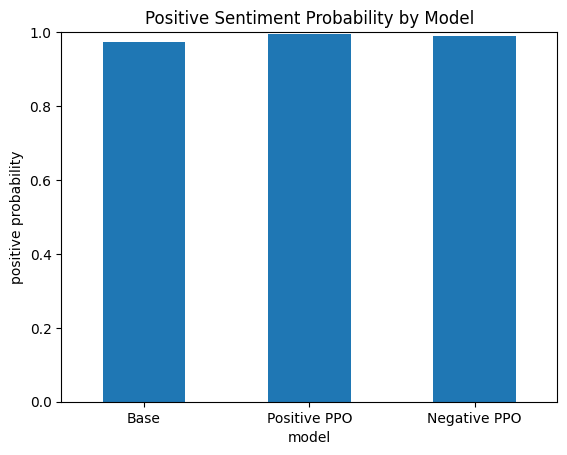

In [29]:
if not comparison.empty:
    ax = comparison.plot(
        x="model",
        y="positive_probability",
        kind="bar",
        legend=False,
        rot=0,
        title="Positive Sentiment Probability by Model",
    )
    ax.set_ylabel("positive probability")
    plt.ylim(0, 1)
    plt.show()